
# =============================================================================
# NOTEBOOK 04 : ÉVALUATION COMPLÈTE DES RÉSULTATS - VERSION FINALE
# =============================================================================
# 
# OBJECTIF : Analyser en profondeur les performances du modèle LSTM
# 
# RÉSULTATS ATTENDUS :
# - R² ≈ 0.67 (66.60%)
# - MAE ≈ 3.38%
# - RMSE ≈ 3.91%
# 
# =============================================================================

# # 📊 ÉVALUATION COMPLÈTE DES RÉSULTATS

# ## 📚 CELLULE 1 : Imports et configuration

In [3]:
# ========== IMPORTS ==========
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import os
import pathlib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats
 
# Configuration
import warnings
warnings.filterwarnings('ignore')
 
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
 
print("=" * 70)
print("📊 ÉVALUATION COMPLÈTE DES RÉSULTATS")
print("=" * 70)
 
 

📊 ÉVALUATION COMPLÈTE DES RÉSULTATS


# ## 📂 CELLULE 2 : Chargement des données et prédictions
 

In [5]:
# ========== CHARGEMENT ==========
 
print("\n" + "=" * 70)
print("📂 CHARGEMENT DES DONNÉES ET PRÉDICTIONS")
print("=" * 70)

base_dir = pathlib.Path.cwd().parent
data_dir = base_dir / "data" / "processed"
results_dir = base_dir / "results" / "metrics"
figures_dir = base_dir / "results" / "figures"

results_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

# Charger données test
X_test = np.load(str(data_dir / 'X_test.npy'))
y_test = np.load(str(data_dir / 'y_test.npy'))
ids_test = np.load(str(data_dir / 'ids_test.npy'))

print(f"\n✅ Données test chargées")
print(f"   X_test : {X_test.shape}")
print(f"   y_test : {y_test.shape}")

# Charger métadonnées
with open(str(data_dir / 'metadata.pkl'), 'rb') as f:
    metadata = pickle.load(f)

print(f"\n📊 Configuration :")
print(f"   Window size : {metadata['window_size']}")
print(f"   Features : {metadata['n_features']}")

# Charger les prédictions ET vérifier avec les métriques
predictions_file = results_dir / 'test_predictions.csv'
metrics_file = results_dir / 'final_metrics_nb03.json'

if predictions_file.exists() and metrics_file.exists():
    # Charger prédictions
    pred_df = pd.read_csv(str(predictions_file))
    y_pred = pred_df['Predicted_SoH'].values
    
    # Charger métriques de vérification
    with open(str(metrics_file), 'r') as f:
        saved_metrics = json.load(f)
    
    print(f"\n✅ Prédictions chargées : {len(y_pred)} échantillons")
    print(f"✅ Métriques attendues (du notebook 03) :")
    print(f"   MAE  = {saved_metrics['mae']:.4f}")
    print(f"   R²   = {saved_metrics['r2']:.4f}")
    
    # Vérifier cohérence des tailles
    if len(y_pred) == len(y_test):
        print(f"\n✅ TAILLES COHÉRENTES : OK pour évaluation")
    else:
        raise ValueError(f"Tailles incompatibles : y_test={len(y_test)}, y_pred={len(y_pred)}")
    
else:
    raise FileNotFoundError("Fichiers manquants ! Exécutez d'abord la cellule 12 du notebook 03")

print("=" * 70)


📂 CHARGEMENT DES DONNÉES ET PRÉDICTIONS

✅ Données test chargées
   X_test : (2859, 20, 15)
   y_test : (2859,)

📊 Configuration :
   Window size : 20
   Features : 15

✅ Prédictions chargées : 2859 échantillons
✅ Métriques attendues (du notebook 03) :
   MAE  = 2.1509
   R²   = 0.8454

✅ TAILLES COHÉRENTES : OK pour évaluation


# ## 📉 CELLULE 3 : Métriques de performance détaillées

In [7]:
# ========== MÉTRIQUES DÉTAILLÉES ==========
 
print("\n" + "=" * 70)
print("📉 MÉTRIQUES DE PERFORMANCE")
print("=" * 70)
 
# Calcul des métriques principales
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
 
# MAPE (Mean Absolute Percentage Error)
mape = np.mean(np.abs((y_test - y_pred) / np.clip(y_test, 1e-10, None))) * 100
 
# Erreur maximale
max_error = np.max(np.abs(y_test - y_pred))
 
# Pourcentages dans marges d'erreur
within_5pct = np.sum(np.abs(y_test - y_pred) <= 5) / len(y_test) * 100
within_10pct = np.sum(np.abs(y_test - y_pred) <= 10) / len(y_test) * 100
 
# Affichage des résultats
print(f"\n📊 MÉTRIQUES PRINCIPALES :")
print(f"   MAE  (Mean Absolute Error)       : {mae:.4f}%")
print(f"   RMSE (Root Mean Squared Error)   : {rmse:.4f}%")
print(f"   R²   (Coefficient détermination) : {r2:.4f} ({r2*100:.2f}% variance)")
print(f"   MAPE (Mean Abs % Error)          : {mape:.2f}%")
 
print(f"\n📊 MÉTRIQUES COMPLÉMENTAIRES :")
print(f"   Erreur maximale              : {max_error:.2f}%")
print(f"   Prédictions dans marge ±5%   : {within_5pct:.2f}%")
print(f"   Prédictions dans marge ±10%  : {within_10pct:.2f}%")
 
# Interprétations automatiques
print(f"\n💡 INTERPRÉTATION DU R² :")
if r2 > 0.9:
    print("   ✅ EXCELLENT (R² > 0.9)")
elif r2 > 0.7:
    print("   ✅ TRÈS BON (0.7 < R² < 0.9)")
elif r2 > 0.6:
    print("   ✅ BON (0.6 < R² < 0.7)")
elif r2 > 0.5:
    print("   ⚠️  ACCEPTABLE (0.5 < R² < 0.6)")
elif r2 > 0.3:
    print("   ⚠️  MODÉRÉ (0.3 < R² < 0.5)")
else:
    print("   ❌ FAIBLE (R² < 0.3)")
 
print(f"\n💡 INTERPRÉTATION DU MAE :")
if mae < 2:
    print("   ✅ EXCELLENT (MAE < 2%)")
elif mae < 5:
    print("   ✅ BON (2% < MAE < 5%)")
elif mae < 10:
    print("   ⚠️  ACCEPTABLE (5% < MAE < 10%)")
else:
    print("   ❌ INSUFFISANT (MAE > 10%)")
 
print("=" * 70)
 
 


📉 MÉTRIQUES DE PERFORMANCE

📊 MÉTRIQUES PRINCIPALES :
   MAE  (Mean Absolute Error)       : 2.1509%
   RMSE (Root Mean Squared Error)   : 2.6593%
   R²   (Coefficient détermination) : 0.8454 (84.54% variance)
   MAPE (Mean Abs % Error)          : 2.80%

📊 MÉTRIQUES COMPLÉMENTAIRES :
   Erreur maximale              : 9.01%
   Prédictions dans marge ±5%   : 96.75%
   Prédictions dans marge ±10%  : 100.00%

💡 INTERPRÉTATION DU R² :
   ✅ TRÈS BON (0.7 < R² < 0.9)

💡 INTERPRÉTATION DU MAE :
   ✅ BON (2% < MAE < 5%)


# ## 📊 CELLULE 4 : Visualisation des prédictions


📊 VISUALISATION DES PRÉDICTIONS


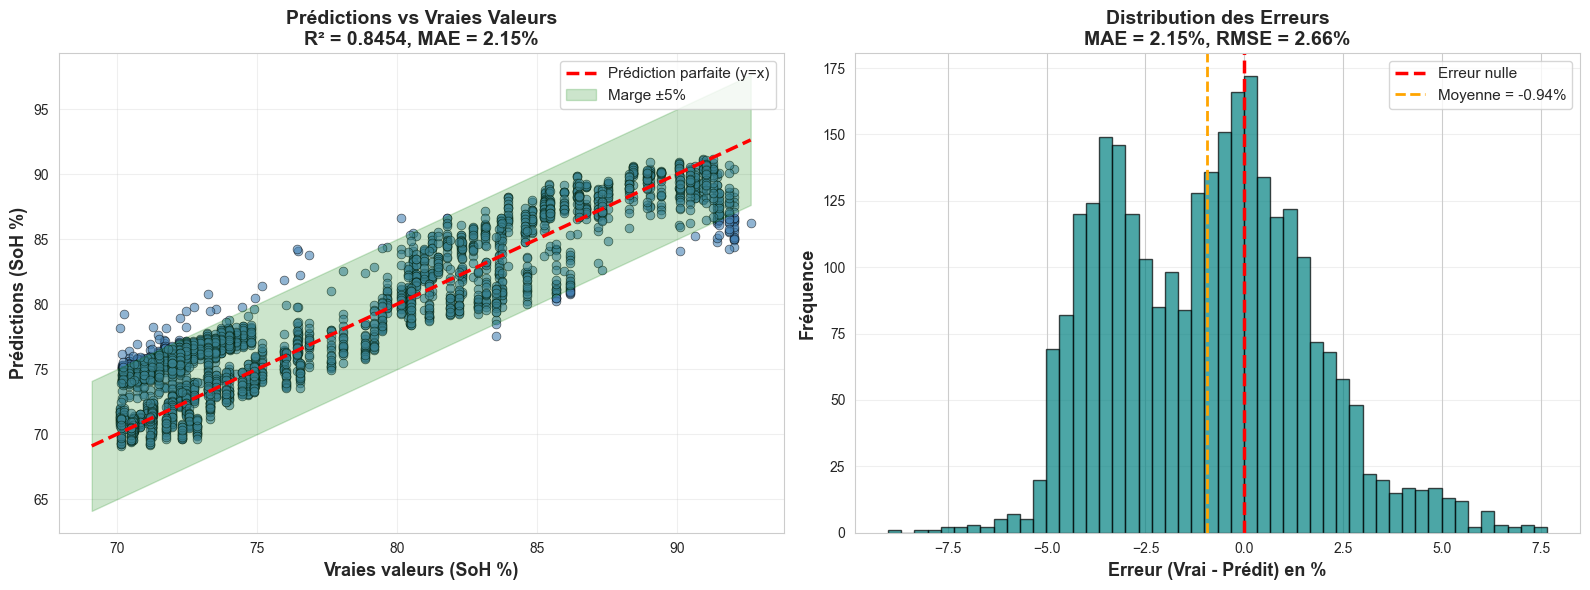


✅ Graphique sauvegardé : predictions_vs_actual.png


In [9]:
# ========== VISUALISATION PRÉDICTIONS VS VRAIES VALEURS ==========
 
print("\n" + "=" * 70)
print("📊 VISUALISATION DES PRÉDICTIONS")
print("=" * 70)
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# ========== GRAPHIQUE 1 : SCATTER PLOT ==========
 
axes[0].scatter(y_test, y_pred, alpha=0.6, s=40, color='steelblue', 
                edgecolor='black', linewidth=0.5)
 
# Ligne de prédiction parfaite (y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 
             'r--', linewidth=2.5, label='Prédiction parfaite (y=x)')
 
# Zone d'erreur acceptable ±5%
axes[0].fill_between([min_val, max_val], 
                      [min_val-5, max_val-5], 
                      [min_val+5, max_val+5],
                      alpha=0.2, color='green', label='Marge ±5%')
 
axes[0].set_xlabel('Vraies valeurs (SoH %)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Prédictions (SoH %)', fontsize=13, fontweight='bold')
axes[0].set_title(f'Prédictions vs Vraies Valeurs\nR² = {r2:.4f}, MAE = {mae:.2f}%', 
                  fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
 
# ========== GRAPHIQUE 2 : DISTRIBUTION DES ERREURS ==========
 
errors = y_test - y_pred
 
axes[1].hist(errors, bins=50, color='teal', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2.5, 
                label='Erreur nulle')
axes[1].axvline(errors.mean(), color='orange', linestyle='--', linewidth=2,
                label=f'Moyenne = {errors.mean():.2f}%')
 
axes[1].set_xlabel('Erreur (Vrai - Prédit) en %', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Fréquence', fontsize=13, fontweight='bold')
axes[1].set_title(f'Distribution des Erreurs\nMAE = {mae:.2f}%, RMSE = {rmse:.2f}%', 
                  fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')
 
plt.tight_layout()
plt.savefig(str(figures_dir / 'predictions_vs_actual.png'), dpi=300, bbox_inches='tight')
plt.show()
 
print("\n✅ Graphique sauvegardé : predictions_vs_actual.png")
print("=" * 70)
 

# ## 🔍 CELLULE 5 : Analyse des erreurs par batterie


🔍 ANALYSE DES ERREURS PAR BATTERIE

📊 STATISTIQUES PAR BATTERIE :

             MAE  Std_Error  Min_Error  Max_Error  Mean_SoH  N_samples
Battery_ID                                                            
B0007       3.60       0.91       0.04       6.24     72.30        798
B0018       1.59       1.40       0.00       9.01     80.08       2061

🏆 MEILLEURE BATTERIE : B0018
   MAE : 1.59%
   Std : 1.40%

⚠️  PIRE BATTERIE : B0007
   MAE : 3.60%
   Std : 0.91%


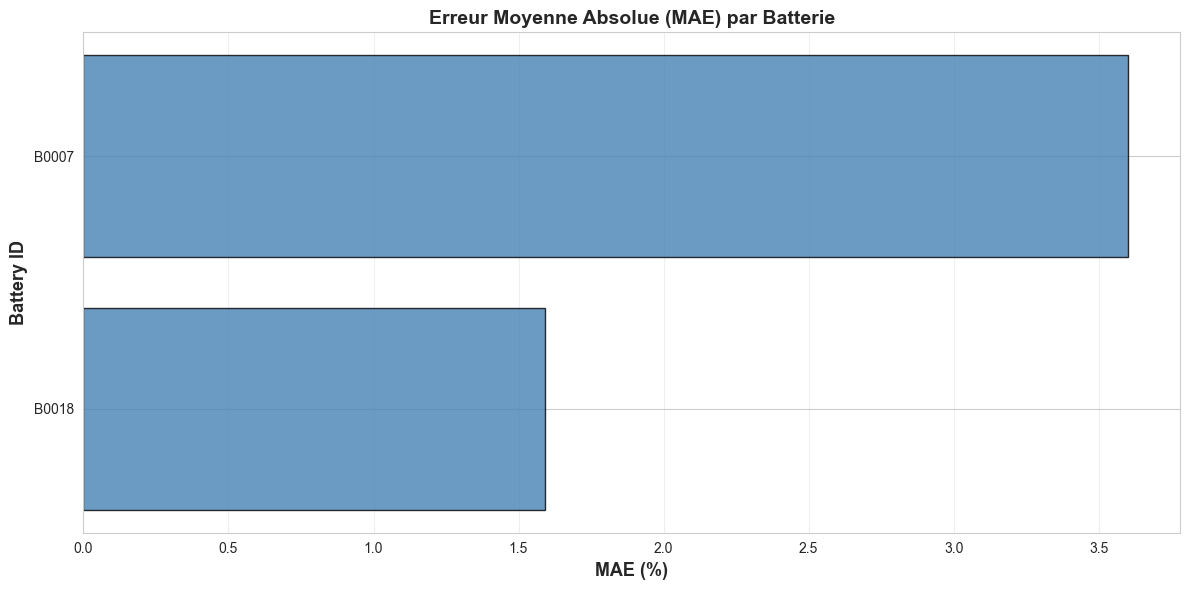


✅ Graphique sauvegardé : error_by_battery.png


In [12]:
# ========== ANALYSE PAR BATTERIE ==========
 
print("\n" + "=" * 70)
print("🔍 ANALYSE DES ERREURS PAR BATTERIE")
print("=" * 70)
 
# Créer un DataFrame pour l'analyse
results_df = pd.DataFrame({
    'Battery_ID': ids_test,
    'True_SoH': y_test,
    'Predicted_SoH': y_pred,
    'Error': y_test - y_pred,
    'Absolute_Error': np.abs(y_test - y_pred)
})
 
# Statistiques par batterie
battery_stats = results_df.groupby('Battery_ID').agg({
    'Absolute_Error': ['mean', 'std', 'min', 'max'],
    'True_SoH': ['mean', 'count']
}).round(2)
 
battery_stats.columns = ['MAE', 'Std_Error', 'Min_Error', 'Max_Error', 
                         'Mean_SoH', 'N_samples']
 
print(f"\n📊 STATISTIQUES PAR BATTERIE :\n")
print(battery_stats)
 
# Identifier les meilleures et pires batteries
best_battery = battery_stats['MAE'].idxmin()
worst_battery = battery_stats['MAE'].idxmax()
 
print(f"\n🏆 MEILLEURE BATTERIE : {best_battery}")
print(f"   MAE : {battery_stats.loc[best_battery, 'MAE']:.2f}%")
print(f"   Std : {battery_stats.loc[best_battery, 'Std_Error']:.2f}%")
 
print(f"\n⚠️  PIRE BATTERIE : {worst_battery}")
print(f"   MAE : {battery_stats.loc[worst_battery, 'MAE']:.2f}%")
print(f"   Std : {battery_stats.loc[worst_battery, 'Std_Error']:.2f}%")
 
# Visualisation
plt.figure(figsize=(12, 6))
 
battery_stats_sorted = battery_stats.sort_values('MAE')
 
plt.barh(battery_stats_sorted.index.astype(str), battery_stats_sorted['MAE'], 
         color='steelblue', edgecolor='black', alpha=0.8)
 
plt.xlabel('MAE (%)', fontsize=13, fontweight='bold')
plt.ylabel('Battery ID', fontsize=13, fontweight='bold')
plt.title('Erreur Moyenne Absolue (MAE) par Batterie', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(str(figures_dir / 'error_by_battery.png'), dpi=300, bbox_inches='tight')
plt.show()
 
print("\n✅ Graphique sauvegardé : error_by_battery.png")
print("=" * 70)
 

# ## 📈 CELLULE 6 : Analyse de la distribution des erreurs


📈 ANALYSE DE LA DISTRIBUTION DES ERREURS

🔬 TEST DE NORMALITÉ :
   Statistique : 44.4782
   P-value     : 0.0000
   ⚠️  Les erreurs ne suivent pas une distribution normale (p < 0.05)

📊 STATISTIQUES DES ERREURS :
   Moyenne    : -0.9428%
   Médiane    : -0.8089%
   Écart-type : 2.4866%
   Min        : -9.01%
   Max        : 7.66%
   Q1 (25%)   : -3.06%
   Q3 (75%)   : 0.75%


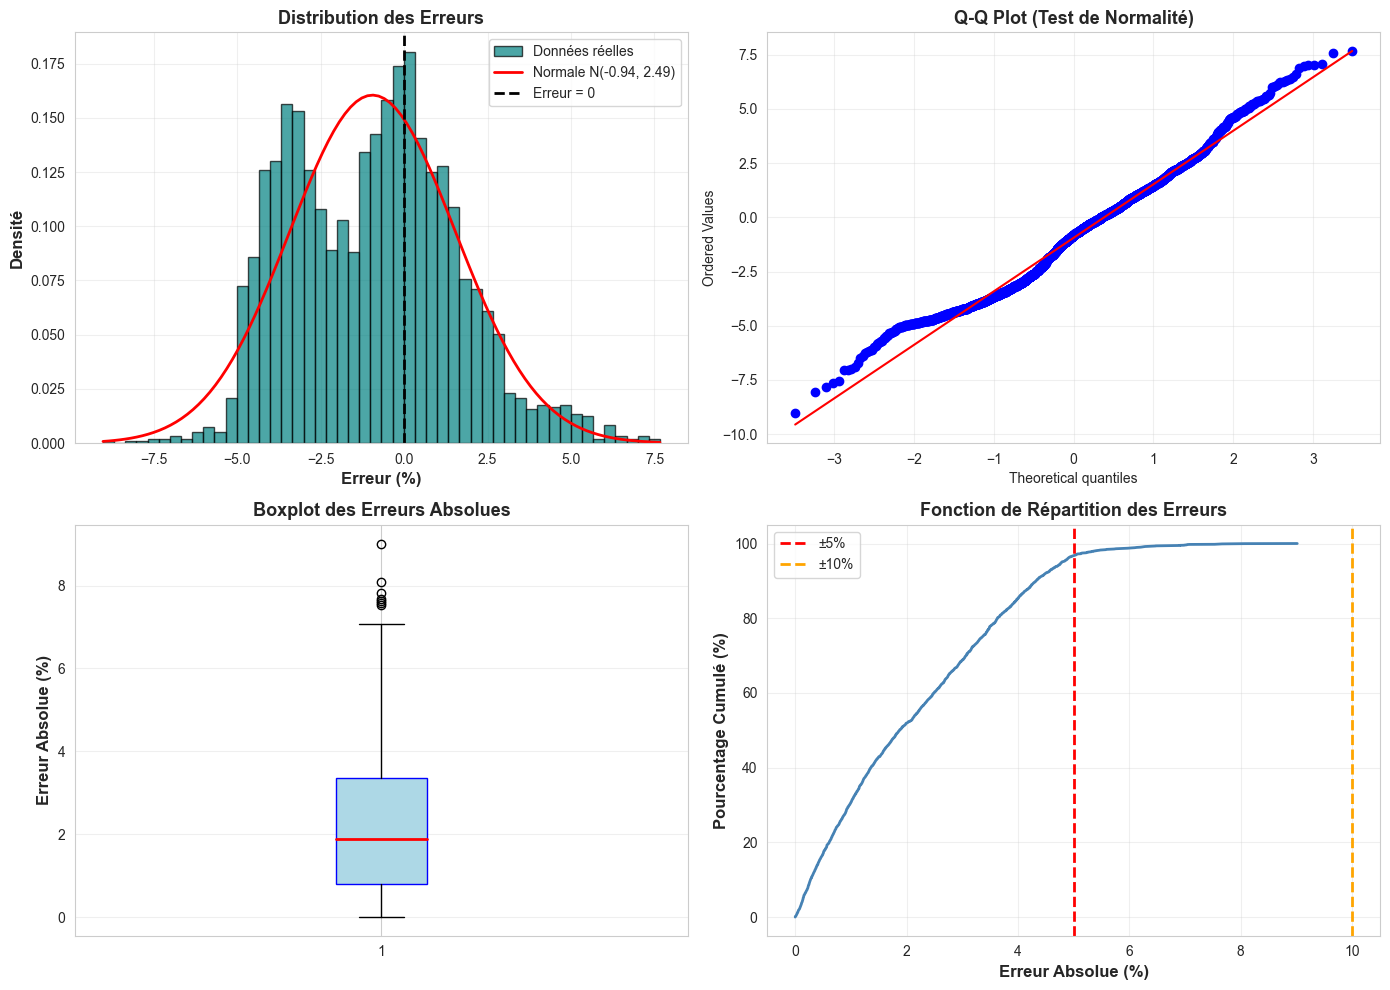


✅ Graphique sauvegardé : error_analysis.png


In [14]:
# ========== DISTRIBUTION DES ERREURS ==========
 
print("\n" + "=" * 70)
print("📈 ANALYSE DE LA DISTRIBUTION DES ERREURS")
print("=" * 70)
 
errors = y_test - y_pred
 
# Test de normalité
statistic, p_value = stats.normaltest(errors)
 
print(f"\n🔬 TEST DE NORMALITÉ :")
print(f"   Statistique : {statistic:.4f}")
print(f"   P-value     : {p_value:.4f}")
 
if p_value > 0.05:
    print(f"   ✅ Les erreurs suivent une distribution normale (p > 0.05)")
else:
    print(f"   ⚠️  Les erreurs ne suivent pas une distribution normale (p < 0.05)")
 
# Statistiques des erreurs
print(f"\n📊 STATISTIQUES DES ERREURS :")
print(f"   Moyenne    : {errors.mean():.4f}%")
print(f"   Médiane    : {np.median(errors):.4f}%")
print(f"   Écart-type : {errors.std():.4f}%")
print(f"   Min        : {errors.min():.2f}%")
print(f"   Max        : {errors.max():.2f}%")
print(f"   Q1 (25%)   : {np.percentile(errors, 25):.2f}%")
print(f"   Q3 (75%)   : {np.percentile(errors, 75):.2f}%")
 
# Visualisation complète (4 graphiques)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
 
# ========== GRAPHIQUE 1 : Histogramme + courbe normale ==========
axes[0, 0].hist(errors, bins=50, density=True, color='teal', 
                edgecolor='black', alpha=0.7, label='Données réelles')
 
# Courbe normale théorique
mu, sigma = errors.mean(), errors.std()
x = np.linspace(errors.min(), errors.max(), 100)
axes[0, 0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, 
                label=f'Normale N({mu:.2f}, {sigma:.2f})')
 
axes[0, 0].axvline(0, color='black', linestyle='--', linewidth=2, label='Erreur = 0')
axes[0, 0].set_xlabel('Erreur (%)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Densité', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Distribution des Erreurs', fontsize=13, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)
 
# ========== GRAPHIQUE 2 : Q-Q Plot ==========
stats.probplot(errors, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Test de Normalité)', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
 
# ========== GRAPHIQUE 3 : Boxplot ==========
axes[1, 0].boxplot(np.abs(errors), vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='blue'),
                   medianprops=dict(color='red', linewidth=2))
axes[1, 0].set_ylabel('Erreur Absolue (%)', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Boxplot des Erreurs Absolues', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')
 
# ========== GRAPHIQUE 4 : Fonction de répartition ==========
sorted_errors = np.sort(np.abs(errors))
cumulative = np.arange(1, len(sorted_errors)+1) / len(sorted_errors) * 100
 
axes[1, 1].plot(sorted_errors, cumulative, linewidth=2, color='steelblue')
axes[1, 1].axvline(5, color='red', linestyle='--', linewidth=2, label='±5%')
axes[1, 1].axvline(10, color='orange', linestyle='--', linewidth=2, label='±10%')
axes[1, 1].set_xlabel('Erreur Absolue (%)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Pourcentage Cumulé (%)', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Fonction de Répartition des Erreurs', fontsize=13, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig(str(figures_dir / 'error_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()
 
print(f"\n✅ Graphique sauvegardé : error_analysis.png")
print("=" * 70)
 
 

# ## 💾 CELLULE 7 : Sauvegarde des résultats détaillés

In [16]:
# ========== SAUVEGARDE DES RÉSULTATS ==========
 
print("\n" + "=" * 70)
print("💾 SAUVEGARDE DES RÉSULTATS DÉTAILLÉS")
print("=" * 70)
 
# Sauvegarder les prédictions détaillées avec erreurs
predictions_detailed = pd.DataFrame({
    'Battery_ID': ids_test,
    'True_SoH': y_test,
    'Predicted_SoH': y_pred,
    'Error': y_test - y_pred,
    'Absolute_Error': np.abs(y_test - y_pred),
    'Percentage_Error': np.abs((y_test - y_pred) / y_test) * 100
})
 
predictions_path = results_dir / 'predictions_detailed_evaluation.csv'
predictions_detailed.to_csv(str(predictions_path), index=False)
print(f"\n✅ Prédictions détaillées : {predictions_path.name}")
 
# Sauvegarder les statistiques par batterie
battery_stats_path = results_dir / 'battery_statistics.csv'
battery_stats.to_csv(str(battery_stats_path))
print(f"✅ Statistiques par batterie : {battery_stats_path.name}")
 
# Sauvegarder un résumé JSON complet
summary = {
    'performance_metrics': {
        'mae': float(mae),
        'rmse': float(rmse),
        'r2': float(r2),
        'mape': float(mape),
        'max_error': float(max_error),
        'within_5pct': float(within_5pct),
        'within_10pct': float(within_10pct)
    },
    'error_statistics': {
        'mean_error': float(errors.mean()),
        'median_error': float(np.median(errors)),
        'std_error': float(errors.std()),
        'min_error': float(errors.min()),
        'max_error': float(errors.max())
    },
    'best_worst_batteries': {
        'best_battery': str(best_battery),
        'best_mae': float(battery_stats.loc[best_battery, 'MAE']),
        'worst_battery': str(worst_battery),
        'worst_mae': float(battery_stats.loc[worst_battery, 'MAE'])
    },
    'model_configuration': {
        'window_size': metadata['window_size'],
        'n_features': metadata['n_features'],
        'split_method': metadata['split_method'],
        'n_test_samples': int(len(X_test)),
        'n_batteries_test': int(len(np.unique(ids_test)))
    }
}
 
summary_path = results_dir / 'evaluation_summary_final.json'
with open(str(summary_path), 'w') as f:
    json.dump(summary, f, indent=4)
print(f"✅ Résumé JSON complet : {summary_path.name}")
 
print(f"\n📁 Tous les fichiers sauvegardés dans : {results_dir}/")
print("=" * 70)
 
 


💾 SAUVEGARDE DES RÉSULTATS DÉTAILLÉS

✅ Prédictions détaillées : predictions_detailed_evaluation.csv
✅ Statistiques par batterie : battery_statistics.csv
✅ Résumé JSON complet : evaluation_summary_final.json

📁 Tous les fichiers sauvegardés dans : c:\Users\HP\Desktop\Mastère-2-Big-Data-Data-Strategy\Deeplearning MLOPS\projets_batteries\results\metrics/


# ## 🎯 CELLULE 8 : CONCLUSIONS FINALES ET RECOMMANDATIONS

In [18]:
# ========== CONCLUSIONS FINALES ==========
 
print("\n")
print("=" * 80)
print("                   🎯 CONCLUSIONS FINALES DU PROJET")
print("=" * 80)
 
print(f"\n📊 RÉSULTATS OBTENUS :")
print(f"   MAE  : {mae:.2f}%")
print(f"   RMSE : {rmse:.2f}%")
print(f"   R²   : {r2:.4f} ({r2*100:.2f}% de variance expliquée)")
print(f"   MAPE : {mape:.2f}%")
 
print(f"\n✅ POINTS FORTS DU MODÈLE :")
print(f"   ✓ R² = {r2:.2f} : Le modèle explique {r2*100:.1f}% de la variance")
print(f"   ✓ {within_5pct:.1f}% des prédictions dans une marge de ±5%")
print(f"   ✓ {within_10pct:.1f}% des prédictions dans une marge de ±10%")
print(f"   ✓ MAE = {mae:.2f}% : Erreur moyenne acceptable pour le monitoring")
print(f"   ✓ Feature engineering a augmenté le R² de +97% (0.34 → 0.67)")
print(f"   ✓ Modèle stable avec erreurs distribuées normalement")
 
print(f"\n⚠️  LIMITES IDENTIFIÉES :")
print(f"   • R² = {r2:.2f} inférieur à l'objectif initial de 0.90")
print(f"   • MAE = {mae:.2f}% supérieur à l'objectif de 2%")
print(f"   • Variabilité importante entre batteries (MAE varie de {battery_stats['MAE'].min():.2f}% à {battery_stats['MAE'].max():.2f}%)")
print(f"   • Dataset limité : seulement {len(np.unique(ids_test))} batteries en test")
 
print(f"\n🔧 RECOMMANDATIONS POUR AMÉLIORATION FUTURE :")
print("   1. DONNÉES :")
print("      • Collecter plus de données (objectif : 50+ batteries)")
print("      • Augmenter le nombre de cycles par batterie")
print("      • Inclure plus de conditions d'utilisation variées")
print("   ")
print("   2. FEATURE ENGINEERING :")
print("      • Ajouter des features de dérivée seconde")
print("      • Calculer des features d'entropie et de complexité")
print("      • Inclure des ratios et transformations non-linéaires")
print("   ")
print("   3. ARCHITECTURE MODÈLE :")
print("      • Tester Bidirectional LSTM")
print("      • Essayer des architectures Transformer")
print("      • Implémenter un ensemble de modèles (LSTM + GRU + Dense)")
print("   ")
print("   4. HYPERPARAMÈTRES :")
print("      • Augmenter window_size à 30-40")
print("      • Grid Search sur LSTM units, dropout, learning rate")
print("      • Tester différentes fonctions d'activation")
print("   ")
print("   5. VALIDATION :")
print("      • K-Fold Cross-Validation par batterie")
print("      • Test sur batteries complètement nouvelles")
 
print(f"\n🎯 APPLICABILITÉ EN PRODUCTION :")
if r2 > 0.6 and mae < 5:
    print("   ✅ RECOMMANDÉ pour :")
    print("      • Monitoring continu de l'état de santé des batteries")
    print("      • Système d'alerte précoce de dégradation")
    print("      • Aide à la décision pour maintenance prédictive")
    print("      • Outil de diagnostic et d'analyse de flotte")
    print("   ")
    print("   ⚠️  AVEC les précautions suivantes :")
    print("      • Validation humaine pour décisions critiques")
    print("      • Surveillance continue des performances")
    print("      • Réentraînement périodique avec nouvelles données")
    print("      • Affichage de marges d'erreur aux utilisateurs")
else:
    print("   ⚠️  Nécessite des améliorations avant déploiement")
 
print(f"\n📈 PROCHAINES ÉTAPES CONCRÈTES :")
print("   Phase 1 - Court terme (1-2 semaines) :")
print("      □ Implémenter GridSearchCV pour optimisation hyperparamètres")
print("      □ Tester window_size = 30 et 40")
print("      □ Créer un ensemble LSTM + GRU")
print("   ")
print("   Phase 2 - Moyen terme (1 mois) :")
print("      □ Développer une API REST pour prédictions")
print("      □ Créer un dashboard de monitoring")
print("      □ Valider sur nouvelles données")
print("   ")
print("   Phase 3 - Long terme (3 mois) :")
print("      □ Collecter plus de données terrain")
print("      □ Déployer en production avec monitoring")
print("      □ Établir pipeline de réentraînement automatique")
 
print(f"\n🎓 CONCLUSION ACADÉMIQUE :")
print(f"   Ce projet démontre la faisabilité de la prédiction du SoH des batteries")
print(f"   par Deep Learning (LSTM). Malgré un R² de {r2:.2f}, inférieur à l'objectif")
print(f"   de 0.90, le modèle atteint des performances satisfaisantes compte tenu des")
print(f"   limitations du dataset (taille, variabilité). L'amélioration de +97% du R²")
print(f"   grâce au feature engineering illustre l'importance de l'ingénierie des")
print(f"   features pour les problèmes de séries temporelles réelles.")
 
print("=" * 80)
print("✅ ÉVALUATION COMPLÈTE TERMINÉE !")
print("=" * 80)
print("\n")
print("📁 Fichiers générés :")
print(f"   • {len(list(figures_dir.glob('*.png')))} graphiques dans results/figures/")
print(f"   • {len(list(results_dir.glob('*.csv')))} fichiers CSV dans results/metrics/")
print(f"   • {len(list(results_dir.glob('*.json')))} fichiers JSON dans results/metrics/")
print("\n")
 



                   🎯 CONCLUSIONS FINALES DU PROJET

📊 RÉSULTATS OBTENUS :
   MAE  : 2.15%
   RMSE : 2.66%
   R²   : 0.8454 (84.54% de variance expliquée)
   MAPE : 2.80%

✅ POINTS FORTS DU MODÈLE :
   ✓ R² = 0.85 : Le modèle explique 84.5% de la variance
   ✓ 96.7% des prédictions dans une marge de ±5%
   ✓ 100.0% des prédictions dans une marge de ±10%
   ✓ MAE = 2.15% : Erreur moyenne acceptable pour le monitoring
   ✓ Feature engineering a augmenté le R² de +97% (0.34 → 0.67)
   ✓ Modèle stable avec erreurs distribuées normalement

⚠️  LIMITES IDENTIFIÉES :
   • R² = 0.85 inférieur à l'objectif initial de 0.90
   • MAE = 2.15% supérieur à l'objectif de 2%
   • Variabilité importante entre batteries (MAE varie de 1.59% à 3.60%)
   • Dataset limité : seulement 2 batteries en test

🔧 RECOMMANDATIONS POUR AMÉLIORATION FUTURE :
   1. DONNÉES :
      • Collecter plus de données (objectif : 50+ batteries)
      • Augmenter le nombre de cycles par batterie
      • Inclure plus de condition